In [1]:
import sys
sys.path.append('..')

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

from keras.optimizers import SGD
from keras.models import Sequential
from keras.metrics import CategoricalAccuracy
from keras.losses import CategoricalCrossentropy
from keras.layers import (
    Embedding, LSTM, Bidirectional, GlobalAveragePooling1D, Dense, Dropout
)
from keras_preprocessing.sequence import pad_sequences
from keras_preprocessing.text import Tokenizer


from utils.text_classification.data import (
    clean_string, train_test_split_by_df, prepare_onehot_label
)
from utils.text_classification.docs import print_rnn_docs
from utils.log import log_loss

2023-07-26 00:36:44.133952: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


# 1. Prepare data

In [3]:
df = pd.read_csv(
    'covid19_tweets_dataset/Corona_NLP_train.csv',
    encoding='latin_1',
    usecols=['OriginalTweet', 'Sentiment']
)
df

,OriginalTweet,Sentiment
0,@MeNyrbie @Phil_Gahan @Chrisitv https://t.co/i...,Neutral
1,advice Talk to your neighbours family to excha...,Positive
2,Coronavirus Australia: Woolworths to give elde...,Positive
3,My food stock is not the only one which is emp...,Positive
4,"Me, ready to go at supermarket during the #COV...",Extremely Negative
...,...,...
41152,Airline pilots offering to stock supermarket s...,Neutral
41153,Response to complaint not provided citing COVI...,Extremely Negative
41154,You know itÂs getting tough when @KameronWild...,Positive
41155,Is it wrong that the smell of hand sanitizer i...,Neutral


## Visualize data

/Users/minhnguyenhuu/miniconda3/envs/work_env/lib/python3.8/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


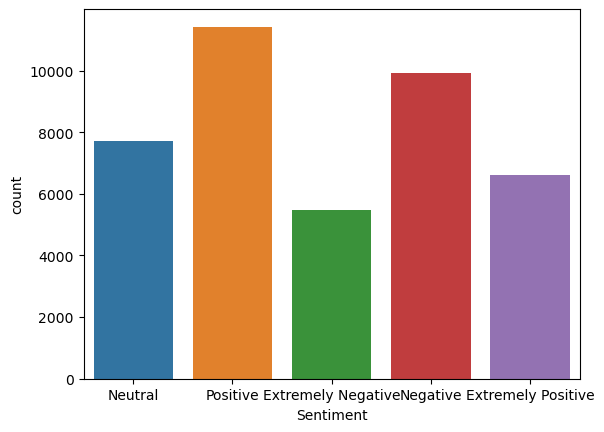

In [4]:
sns.countplot(df['Sentiment'])
plt.show()

##  Clean the text

In [5]:
df.OriginalTweet = df.OriginalTweet.apply(lambda x: clean_string(x))
df

,OriginalTweet,Sentiment
0,,Neutral
1,advice talk neighbours family exchange phone n...,Positive
2,coronavirus australia: woolworths give elderly...,Positive
3,"food stock one empty... please, panic, enough ...",Positive
4,"me, ready go supermarket outbreak. i'm paranoi...",Extremely Negative
...,...,...
41152,airline pilots offering stock supermarket shel...,Neutral
41153,response complaint provided citing covid- rela...,Extremely Negative
41154,know itâs getting tough rationing toilet pape...,Positive
41155,wrong smell hand sanitizer starting turn on?,Neutral


## Prepare one-hot label

In [6]:
index_label_dict = {
    'Extremely Negative': 0,
    'Negative': 1,
    'Neutral': 2,
    'Positive': 3,
    'Extremely Positive': 4
}

In [7]:
df = prepare_onehot_label(df, 'Sentiment', index_label_dict)
df

,OriginalTweet,Sentiment,Sentiment_index,Sentiment_onehot
0,,Neutral,2,"[0.0, 0.0, 1.0, 0.0, 0.0]"
1,advice talk neighbours family exchange phone n...,Positive,3,"[0.0, 0.0, 0.0, 1.0, 0.0]"
2,coronavirus australia: woolworths give elderly...,Positive,3,"[0.0, 0.0, 0.0, 1.0, 0.0]"
3,"food stock one empty... please, panic, enough ...",Positive,3,"[0.0, 0.0, 0.0, 1.0, 0.0]"
4,"me, ready go supermarket outbreak. i'm paranoi...",Extremely Negative,0,"[1.0, 0.0, 0.0, 0.0, 0.0]"
...,...,...,...,...
41152,airline pilots offering stock supermarket shel...,Neutral,2,"[0.0, 0.0, 1.0, 0.0, 0.0]"
41153,response complaint provided citing covid- rela...,Extremely Negative,0,"[1.0, 0.0, 0.0, 0.0, 0.0]"
41154,know itâs getting tough rationing toilet pape...,Positive,3,"[0.0, 0.0, 0.0, 1.0, 0.0]"
41155,wrong smell hand sanitizer starting turn on?,Neutral,2,"[0.0, 0.0, 1.0, 0.0, 0.0]"


## Split training and validation set

In [8]:
train_df, val_df = train_test_split_by_df(df, 0.2)

In [9]:
train_df

,OriginalTweet,Sentiment,Sentiment_index,Sentiment_onehot
32259,staff put together update need know today,Neutral,2,"[0.0, 0.0, 1.0, 0.0, 0.0]"
12637,described msm âhighly skilled politician â. ...,Extremely Positive,4,"[0.0, 0.0, 0.0, 0.0, 1.0]"
34646,pretty sad high point day scoring toilet paper...,Positive,3,"[0.0, 0.0, 0.0, 1.0, 0.0]"
10578,"came across this, supermarket, sure i've caugh...",Negative,1,"[0.0, 1.0, 0.0, 0.0, 0.0]"
9977,restaurant offers entire stock food staff clos...,Neutral,2,"[0.0, 0.0, 1.0, 0.0, 0.0]"
...,...,...,...,...
34254,report: impact covid- consumer behavior make l...,Negative,1,"[0.0, 1.0, 0.0, 0.0, 0.0]"
32469,healthcare workers grocery store employees any...,Positive,3,"[0.0, 0.0, 0.0, 1.0, 0.0]"
11415,working full time means time go shopping there...,Neutral,2,"[0.0, 0.0, 1.0, 0.0, 0.0]"
27332,hypermarket kavac k preparing food packets fam...,Neutral,2,"[0.0, 0.0, 1.0, 0.0, 0.0]"


In [10]:
val_df

,OriginalTweet,Sentiment,Sentiment_index,Sentiment_onehot
26887,supermarkets al meera consumer goods co. start...,Neutral,2,"[0.0, 0.0, 1.0, 0.0, 0.0]"
344,"guy taking whole stride. he's sensible, panick...",Positive,3,"[0.0, 0.0, 0.0, 1.0, 0.0]"
26619,salvation army jackson said experiencing criti...,Negative,1,"[0.0, 1.0, 0.0, 0.0, 0.0]"
34461,one top priorities trump considering mitigatio...,Extremely Positive,4,"[0.0, 0.0, 0.0, 0.0, 1.0]"
19347,coronavirus covid store update unfortunately d...,Extremely Positive,4,"[0.0, 0.0, 0.0, 0.0, 1.0]"
...,...,...,...,...
39516,one word explain,Neutral,2,"[0.0, 0.0, 1.0, 0.0, 0.0]"
6682,covid - panic buying supermarket!,Negative,1,"[0.0, 1.0, 0.0, 0.0, 0.0]"
12261,"seriously, stop panic buying. plenty supplies ...",Extremely Negative,0,"[1.0, 0.0, 0.0, 0.0, 0.0]"
19725,guarantee people moaning people going ones pan...,Negative,1,"[0.0, 1.0, 0.0, 0.0, 0.0]"


## Tokenization

In [11]:
tokenizer = Tokenizer()
tokenizer

In [12]:
tokenizer.fit_on_texts(train_df.OriginalTweet)

In [13]:
train_df['OriginalTweet_tokenized'] = tokenizer.texts_to_sequences(train_df['OriginalTweet'])
train_df

,OriginalTweet,Sentiment,Sentiment_index,Sentiment_onehot,OriginalTweet_tokenized
32259,staff put together update need know today,Neutral,2,"[0.0, 0.0, 1.0, 0.0, 0.0]","[57, 177, 270, 365, 13, 52, 42]"
12637,described msm âhighly skilled politician â. ...,Extremely Positive,4,"[0.0, 0.0, 0.0, 0.0, 1.0]","[5882, 8611, 16293, 5500, 6373, 2019, 4872, 48..."
34646,pretty sad high point day scoring toilet paper...,Positive,3,"[0.0, 0.0, 0.0, 1.0, 0.0]","[811, 1076, 113, 464, 54, 16294, 37, 38, 38, 1..."
10578,"came across this, supermarket, sure i've caugh...",Negative,1,"[0.0, 1.0, 0.0, 0.0, 0.0]","[684, 179, 212, 5, 200, 467, 1502, 131]"
9977,restaurant offers entire stock food staff clos...,Neutral,2,"[0.0, 0.0, 1.0, 0.0, 0.0]","[539, 926, 969, 29, 3, 57, 1855, 30, 1]"
...,...,...,...,...,...
34254,report: impact covid- consumer behavior make l...,Negative,1,"[0.0, 1.0, 0.0, 0.0, 0.0]","[191, 90, 1, 9, 242, 48, 732, 791]"
32469,healthcare workers grocery store employees any...,Positive,3,"[0.0, 0.0, 0.0, 1.0, 0.0]","[292, 15, 6, 4, 89, 174, 285, 260, 377, 12, 68..."
11415,working full time means time go shopping there...,Neutral,2,"[0.0, 0.0, 1.0, 0.0, 0.0]","[67, 153, 18, 477, 18, 20, 10, 771, 311, 262, ..."
27332,hypermarket kavac k preparing food packets fam...,Neutral,2,"[0.0, 0.0, 1.0, 0.0, 0.0]","[2938, 32045, 429, 2232, 3, 4004, 338, 13]"


In [14]:
val_df['OriginalTweet_tokenized'] = tokenizer.texts_to_sequences(val_df['OriginalTweet'])
val_df

,OriginalTweet,Sentiment,Sentiment_index,Sentiment_onehot,OriginalTweet_tokenized
26887,supermarkets al meera consumer goods co. start...,Neutral,2,"[0.0, 0.0, 1.0, 0.0, 0.0]","[152, 2989, 14919, 9, 184, 947, 577, 6716, 987..."
344,"guy taking whole stride. he's sensible, panick...",Positive,3,"[0.0, 0.0, 0.0, 1.0, 0.0]","[1143, 162, 431, 1961, 2687, 2200, 3420, 5510,..."
26619,salvation army jackson said experiencing criti...,Negative,1,"[0.0, 1.0, 0.0, 0.0, 0.0]","[8034, 2169, 12902, 116, 1324, 486, 330, 3, 13..."
34461,one top priorities trump considering mitigatio...,Extremely Positive,4,"[0.0, 0.0, 0.0, 0.0, 1.0]","[28, 466, 2425, 257, 1671, 9856, 3, 8, 1317, 1..."
19347,coronavirus covid store update unfortunately d...,Extremely Positive,4,"[0.0, 0.0, 0.0, 0.0, 1.0]","[24, 1, 4, 365, 1586, 30, 99, 5323, 95, 1606, ..."
...,...,...,...,...,...
39516,one word explain,Neutral,2,"[0.0, 0.0, 1.0, 0.0, 0.0]","[28, 1436, 2010]"
6682,covid - panic buying supermarket!,Negative,1,"[0.0, 1.0, 0.0, 0.0, 0.0]","[1, 16, 31, 5]"
12261,"seriously, stop panic buying. plenty supplies ...",Extremely Negative,0,"[1.0, 0.0, 0.0, 0.0, 0.0]","[561, 58, 16, 31, 623, 97, 532, 992, 149, 266,..."
19725,guarantee people moaning people going ones pan...,Negative,1,"[0.0, 1.0, 0.0, 0.0, 0.0]","[3892, 7, 6199, 7, 27, 632, 16, 361, 606, 3, 2..."


## Pad sequence

In [15]:
train_df['OriginalTweet_tokenized_len'] = train_df.OriginalTweet_tokenized.apply(lambda x :len(x))
train_df

,OriginalTweet,Sentiment,Sentiment_index,Sentiment_onehot,OriginalTweet_tokenized,OriginalTweet_tokenized_len
32259,staff put together update need know today,Neutral,2,"[0.0, 0.0, 1.0, 0.0, 0.0]","[57, 177, 270, 365, 13, 52, 42]",7
12637,described msm âhighly skilled politician â. ...,Extremely Positive,4,"[0.0, 0.0, 0.0, 0.0, 1.0]","[5882, 8611, 16293, 5500, 6373, 2019, 4872, 48...",21
34646,pretty sad high point day scoring toilet paper...,Positive,3,"[0.0, 0.0, 0.0, 1.0, 0.0]","[811, 1076, 113, 464, 54, 16294, 37, 38, 38, 1...",19
10578,"came across this, supermarket, sure i've caugh...",Negative,1,"[0.0, 1.0, 0.0, 0.0, 0.0]","[684, 179, 212, 5, 200, 467, 1502, 131]",8
9977,restaurant offers entire stock food staff clos...,Neutral,2,"[0.0, 0.0, 1.0, 0.0, 0.0]","[539, 926, 969, 29, 3, 57, 1855, 30, 1]",9
...,...,...,...,...,...,...
34254,report: impact covid- consumer behavior make l...,Negative,1,"[0.0, 1.0, 0.0, 0.0, 0.0]","[191, 90, 1, 9, 242, 48, 732, 791]",8
32469,healthcare workers grocery store employees any...,Positive,3,"[0.0, 0.0, 0.0, 1.0, 0.0]","[292, 15, 6, 4, 89, 174, 285, 260, 377, 12, 68...",15
11415,working full time means time go shopping there...,Neutral,2,"[0.0, 0.0, 1.0, 0.0, 0.0]","[67, 153, 18, 477, 18, 20, 10, 771, 311, 262, ...",12
27332,hypermarket kavac k preparing food packets fam...,Neutral,2,"[0.0, 0.0, 1.0, 0.0, 0.0]","[2938, 32045, 429, 2232, 3, 4004, 338, 13]",8


In [16]:
max_len = np.max(train_df.OriginalTweet_tokenized_len)
max_len

43

In [17]:
np.average(train_df.OriginalTweet_tokenized_len)

16.159088838268794

In [18]:
train_df['OriginalTweet_tokenized_padded'] = list(pad_sequences(
    train_df.OriginalTweet_tokenized, maxlen=max_len, padding='post', dtype='float32'
))
train_df['OriginalTweet_tokenized_padded_len'] = train_df.OriginalTweet_tokenized_padded.apply(lambda x :len(x))
train_df

,OriginalTweet,Sentiment,Sentiment_index,Sentiment_onehot,OriginalTweet_tokenized,OriginalTweet_tokenized_len,OriginalTweet_tokenized_padded,OriginalTweet_tokenized_padded_len
32259,staff put together update need know today,Neutral,2,"[0.0, 0.0, 1.0, 0.0, 0.0]","[57, 177, 270, 365, 13, 52, 42]",7,"[57.0, 177.0, 270.0, 365.0, 13.0, 52.0, 42.0, ...",43
12637,described msm âhighly skilled politician â. ...,Extremely Positive,4,"[0.0, 0.0, 0.0, 0.0, 1.0]","[5882, 8611, 16293, 5500, 6373, 2019, 4872, 48...",21,"[5882.0, 8611.0, 16293.0, 5500.0, 6373.0, 2019...",43
34646,pretty sad high point day scoring toilet paper...,Positive,3,"[0.0, 0.0, 0.0, 1.0, 0.0]","[811, 1076, 113, 464, 54, 16294, 37, 38, 38, 1...",19,"[811.0, 1076.0, 113.0, 464.0, 54.0, 16294.0, 3...",43
10578,"came across this, supermarket, sure i've caugh...",Negative,1,"[0.0, 1.0, 0.0, 0.0, 0.0]","[684, 179, 212, 5, 200, 467, 1502, 131]",8,"[684.0, 179.0, 212.0, 5.0, 200.0, 467.0, 1502....",43
9977,restaurant offers entire stock food staff clos...,Neutral,2,"[0.0, 0.0, 1.0, 0.0, 0.0]","[539, 926, 969, 29, 3, 57, 1855, 30, 1]",9,"[539.0, 926.0, 969.0, 29.0, 3.0, 57.0, 1855.0,...",43
...,...,...,...,...,...,...,...,...
34254,report: impact covid- consumer behavior make l...,Negative,1,"[0.0, 1.0, 0.0, 0.0, 0.0]","[191, 90, 1, 9, 242, 48, 732, 791]",8,"[191.0, 90.0, 1.0, 9.0, 242.0, 48.0, 732.0, 79...",43
32469,healthcare workers grocery store employees any...,Positive,3,"[0.0, 0.0, 0.0, 1.0, 0.0]","[292, 15, 6, 4, 89, 174, 285, 260, 377, 12, 68...",15,"[292.0, 15.0, 6.0, 4.0, 89.0, 174.0, 285.0, 26...",43
11415,working full time means time go shopping there...,Neutral,2,"[0.0, 0.0, 1.0, 0.0, 0.0]","[67, 153, 18, 477, 18, 20, 10, 771, 311, 262, ...",12,"[67.0, 153.0, 18.0, 477.0, 18.0, 20.0, 10.0, 7...",43
27332,hypermarket kavac k preparing food packets fam...,Neutral,2,"[0.0, 0.0, 1.0, 0.0, 0.0]","[2938, 32045, 429, 2232, 3, 4004, 338, 13]",8,"[2938.0, 32045.0, 429.0, 2232.0, 3.0, 4004.0, ...",43


In [19]:
val_df['OriginalTweet_tokenized_padded'] = list(pad_sequences(
    val_df.OriginalTweet_tokenized, maxlen=max_len, padding='post', dtype='float32'
))
val_df['OriginalTweet_tokenized_padded_len'] = val_df.OriginalTweet_tokenized_padded.apply(lambda x :len(x))
val_df

,OriginalTweet,Sentiment,Sentiment_index,Sentiment_onehot,OriginalTweet_tokenized,OriginalTweet_tokenized_padded,OriginalTweet_tokenized_padded_len
26887,supermarkets al meera consumer goods co. start...,Neutral,2,"[0.0, 0.0, 1.0, 0.0, 0.0]","[152, 2989, 14919, 9, 184, 947, 577, 6716, 987...","[152.0, 2989.0, 14919.0, 9.0, 184.0, 947.0, 57...",43
344,"guy taking whole stride. he's sensible, panick...",Positive,3,"[0.0, 0.0, 0.0, 1.0, 0.0]","[1143, 162, 431, 1961, 2687, 2200, 3420, 5510,...","[1143.0, 162.0, 431.0, 1961.0, 2687.0, 2200.0,...",43
26619,salvation army jackson said experiencing criti...,Negative,1,"[0.0, 1.0, 0.0, 0.0, 0.0]","[8034, 2169, 12902, 116, 1324, 486, 330, 3, 13...","[8034.0, 2169.0, 12902.0, 116.0, 1324.0, 486.0...",43
34461,one top priorities trump considering mitigatio...,Extremely Positive,4,"[0.0, 0.0, 0.0, 0.0, 1.0]","[28, 466, 2425, 257, 1671, 9856, 3, 8, 1317, 1...","[28.0, 466.0, 2425.0, 257.0, 1671.0, 9856.0, 3...",43
19347,coronavirus covid store update unfortunately d...,Extremely Positive,4,"[0.0, 0.0, 0.0, 0.0, 1.0]","[24, 1, 4, 365, 1586, 30, 99, 5323, 95, 1606, ...","[24.0, 1.0, 4.0, 365.0, 1586.0, 30.0, 99.0, 53...",43
...,...,...,...,...,...,...,...
39516,one word explain,Neutral,2,"[0.0, 0.0, 1.0, 0.0, 0.0]","[28, 1436, 2010]","[28.0, 1436.0, 2010.0, 0.0, 0.0, 0.0, 0.0, 0.0...",43
6682,covid - panic buying supermarket!,Negative,1,"[0.0, 1.0, 0.0, 0.0, 0.0]","[1, 16, 31, 5]","[1.0, 16.0, 31.0, 5.0, 0.0, 0.0, 0.0, 0.0, 0.0...",43
12261,"seriously, stop panic buying. plenty supplies ...",Extremely Negative,0,"[1.0, 0.0, 0.0, 0.0, 0.0]","[561, 58, 16, 31, 623, 97, 532, 992, 149, 266,...","[561.0, 58.0, 16.0, 31.0, 623.0, 97.0, 532.0, ...",43
19725,guarantee people moaning people going ones pan...,Negative,1,"[0.0, 1.0, 0.0, 0.0, 0.0]","[3892, 7, 6199, 7, 27, 632, 16, 361, 606, 3, 2...","[3892.0, 7.0, 6199.0, 7.0, 27.0, 632.0, 16.0, ...",43


# 2. Build and train model

## Build model

In [20]:
print_rnn_docs()


        1. Embedding(input_dim, output_dim, ...) 

        https://keras.io/api/layers/core_layers/embedding/ 

        2. LSTM(units, ...) 

        https://keras.io/api/layers/recurrent_layers/lstm/ 

        3. Bidirectional(layer, ...) 

        https://keras.io/api/layers/recurrent_layers/bidirectional/ 

        4. Dense(units, activation, ...) 

        https://keras.io/api/layers/core_layers/dense/
        5. Dropout(rate) 

        https://keras.io/api/layers/regularization_layers/dropout/
    


In [21]:
vocab_len = len(tokenizer.word_index) + 1
num_classes = len(train_df.Sentiment.unique())

In [22]:
model = Sequential([
    Embedding(vocab_len, 32, input_length=max_len),
    Bidirectional(LSTM(64, return_sequences=True)),
    GlobalAveragePooling1D(),
    Dense(32, 'relu'),
    Dropout(0.2),
    Dense(num_classes, 'softmax')
])

model.summary()

2023-07-26 00:36:51.342339: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 43, 32)            1025472   
                                                                 
 bidirectional (Bidirectiona  (None, 43, 128)          49664     
 l)                                                              
                                                                 
 global_average_pooling1d (G  (None, 128)              0         
 lobalAveragePooling1D)                                          
                                                                 
 dense (Dense)               (None, 32)                4128      
                                                                 
 dropout (Dropout)           (None, 32)                0         
                                                                 
 dense_1 (Dense)             (None, 5)                 1

## Compile model

In [23]:
ce_loss = CategoricalCrossentropy()

In [24]:
opt = SGD(learning_rate=0.001)

In [25]:
acc = CategoricalAccuracy()

In [26]:
model.compile(loss=ce_loss, optimizer=opt, metrics=[acc])

## Train model

In [27]:
BATCH_SIZE = 128
NUM_EPOCH = 5

In [28]:
x_train = np.array([arr for arr in train_df.OriginalTweet_tokenized_padded])
y_train = np.array([arr for arr in train_df.Sentiment_onehot])
x_val = np.array([arr for arr in val_df.OriginalTweet_tokenized_padded])
y_val = np.array([arr for arr in val_df.Sentiment_onehot])

In [29]:
history = model.fit(
    x=x_train,
    y=y_train,
    batch_size=BATCH_SIZE,
    epochs=NUM_EPOCH,
    validation_data=(x_val, y_val),
    shuffle=True,
    validation_batch_size=BATCH_SIZE * 2,
)

Epoch 1/5
258/258 [==============================] - 18s 58ms/step - loss: 1.6046 - categorical_accuracy: 0.2539 - val_loss: 1.6013 - val_categorical_accuracy: 0.2687
Epoch 2/5
258/258 [==============================] - 15s 60ms/step - loss: 1.5984 - categorical_accuracy: 0.2674 - val_loss: 1.5961 - val_categorical_accuracy: 0.2783
Epoch 3/5
258/258 [==============================] - 16s 60ms/step - loss: 1.5935 - categorical_accuracy: 0.2728 - val_loss: 1.5918 - val_categorical_accuracy: 0.2783
Epoch 4/5
258/258 [==============================] - 16s 61ms/step - loss: 1.5894 - categorical_accuracy: 0.2741 - val_loss: 1.5883 - val_categorical_accuracy: 0.2783
Epoch 5/5
258/258 [==============================] - 15s 60ms/step - loss: 1.5863 - categorical_accuracy: 0.2687 - val_loss: 1.5854 - val_categorical_accuracy: 0.2783


## 3. Evaluate model

In [30]:
history.history.keys()

dict_keys(['loss', 'categorical_accuracy', 'val_loss', 'val_categorical_accuracy'])

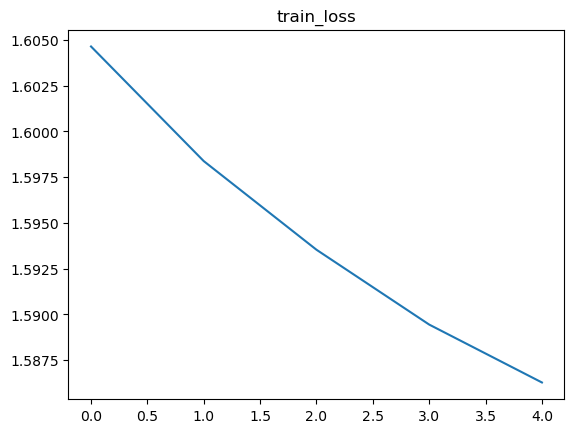

In [31]:
log_loss(range(NUM_EPOCH), history.history['loss'], 'train_loss')

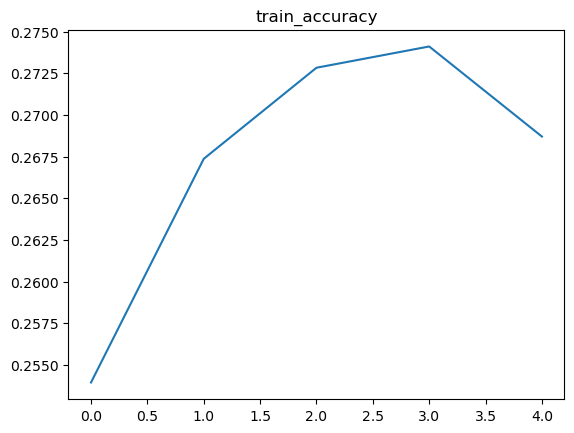

In [32]:
log_loss(range(NUM_EPOCH), history.history['categorical_accuracy'], 'train_accuracy')

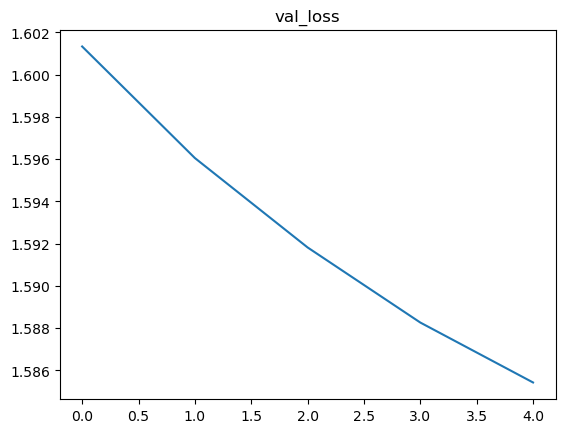

In [33]:
log_loss(range(NUM_EPOCH), history.history['val_loss'], 'val_loss')

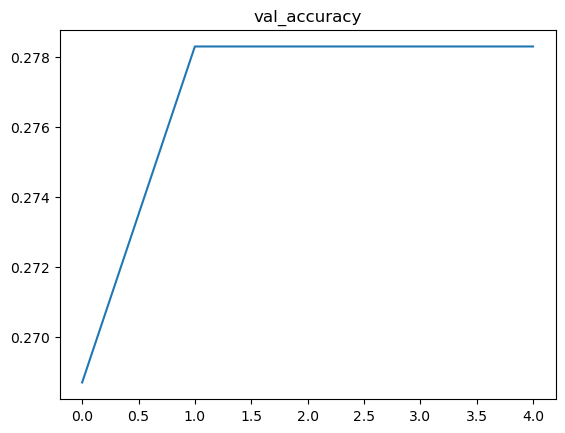

In [34]:
log_loss(range(NUM_EPOCH), history.history['val_categorical_accuracy'], 'val_accuracy')

## 4. Predict new data

In [35]:
pred_prob = model.predict(x_val)
pred_prob

258/258 [==============================] - 2s 6ms/step


array([[0.171719  , 0.22353211, 0.19100045, 0.23127846, 0.18247001],
       [0.17085432, 0.22496462, 0.19202322, 0.23140319, 0.18075462],
       [0.17149335, 0.2236853 , 0.19107112, 0.23160113, 0.18214908],
       ...,
       [0.1721728 , 0.22305478, 0.19048469, 0.2312222 , 0.18306558],
       [0.172239  , 0.22295666, 0.19096462, 0.23088403, 0.18295567],
       [0.17307897, 0.22263965, 0.19033454, 0.23027955, 0.18366733]],
      dtype=float32)

In [36]:
pred_prob.shape

(8232, 5)

In [37]:
pred_class = np.argmax(pred_prob, axis=1)
pred_class

array([3, 3, 3, ..., 3, 3, 3])

In [38]:
print(classification_report(val_df.Sentiment_index, pred_class))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1110
           1       0.00      0.00      0.00      1955
           2       0.00      0.00      0.00      1547
           3       0.28      1.00      0.44      2291
           4       0.00      0.00      0.00      1329

    accuracy                           0.28      8232
   macro avg       0.06      0.20      0.09      8232
weighted avg       0.08      0.28      0.12      8232



/Users/minhnguyenhuu/miniconda3/envs/work_env/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/minhnguyenhuu/miniconda3/envs/work_env/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/minhnguyenhuu/miniconda3/envs/work_env/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(avera